In [53]:
!pip install pymupdf
!pip install pdfplumber
!pip install nltk
!pip install sentence-transformers
!pip install faiss-cpu
!pip install transformers
!pip install torch
!pip install matplotlib
!pip install wordcloud

print("✅ All libraries installed!")

✅ All libraries installed!


In [54]:
# CELL 2

import fitz
import pdfplumber
import nltk
import re
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from wordcloud import WordCloud

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sentence_transformers import SentenceTransformer

import faiss

print("✅ All imports successful!")

✅ All imports successful!


In [55]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

print("✅ NLTK data downloaded!")

stop_words = set(stopwords.words('english'))
print(f"\n📊 Total stopwords in English: {len(stop_words)}")
print(f"🔍 Sample stopwords: {list(stop_words)[:10]}")

✅ NLTK data downloaded!

📊 Total stopwords in English: 198
🔍 Sample stopwords: ['myself', "don't", "needn't", 'it', 'that', "she'd", 'to', 'they', 'further', "he'd"]


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [56]:
# CELL 4

from google.colab import files

print("📂 A file picker will appear below...")
print("👉 Click 'Choose Files' and select your PDF\n")

uploaded = files.upload()

pdf_filename = list(uploaded.keys())[0]
pdf_path = f"/content/{pdf_filename}"

print(f"\n✅ Successfully uploaded!")
print(f"📄 File name : {pdf_filename}")
print(f"📂 File path : {pdf_path}")
print(f"📦 File size : {len(uploaded[pdf_filename]):,} bytes")

📂 A file picker will appear below...
👉 Click 'Choose Files' and select your PDF



Saving 1706.03762v7.pdf to 1706.03762v7 (1).pdf

✅ Successfully uploaded!
📄 File name : 1706.03762v7 (1).pdf
📂 File path : /content/1706.03762v7 (1).pdf
📦 File size : 2,215,244 bytes


In [57]:
# CELL 5

def extract_text(pdf_path):
    """Extract text using PyMuPDF, fallback to pdfplumber"""

    full_text = ""


    try:
        doc = fitz.open(pdf_path)
        print(f"📖 Total pages: {len(doc)}")
        print("-" * 50)

        for page_num in range(len(doc)):
            page = doc[page_num]
            text = page.get_text("text")
            full_text += text + "\n"
            print(f"  ✅ Page {page_num + 1} — {len(text)} characters extracted")

        doc.close()
        print(f"\n🏆 PyMuPDF extracted {len(full_text):,} total characters")

    except Exception as e:
        print(f"⚠️ PyMuPDF failed: {e}")
        print("🔄 Trying pdfplumber instead...")

        with pdfplumber.open(pdf_path) as pdf:
            for i, page in enumerate(pdf.pages):
                text = page.extract_text()
                if text:
                    full_text += text + "\n"
                    print(f"  ✅ Page {i+1} extracted")
                else:
                    print(f"  ⚠️ Page {i+1} — empty (might be image)")

    return full_text

raw_text = extract_text(pdf_path)

print("\n" + "="*55)
print("📝 PREVIEW — First 600 characters of extracted text:")
print("="*55)
print(raw_text[:600])

📖 Total pages: 15
--------------------------------------------------
  ✅ Page 1 — 2858 characters extracted
  ✅ Page 2 — 4256 characters extracted
  ✅ Page 3 — 1827 characters extracted
  ✅ Page 4 — 2508 characters extracted
  ✅ Page 5 — 3193 characters extracted
  ✅ Page 6 — 3473 characters extracted
  ✅ Page 7 — 3321 characters extracted
  ✅ Page 8 — 3194 characters extracted
  ✅ Page 9 — 2973 characters extracted
  ✅ Page 10 — 3112 characters extracted
  ✅ Page 11 — 3216 characters extracted
  ✅ Page 12 — 3214 characters extracted
  ✅ Page 13 — 794 characters extracted
  ✅ Page 14 — 778 characters extracted
  ✅ Page 15 — 781 characters extracted

🏆 PyMuPDF extracted 39,513 total characters

📝 PREVIEW — First 600 characters of extracted text:
Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.

In [58]:
# CELL 6

def clean_text(text):
    """Step by step text cleaning pipeline"""

    print("🧹 Starting text cleaning...")
    original_len = len(text)

    text = re.sub(r'http\S+|www\S+', ' ', text)
    print("  ✅ Step 1: URLs removed")

    text = re.sub(r'\S+@\S+', ' ', text)
    print("  ✅ Step 2: Emails removed")

    text = re.sub(r'[^\w\s\.\,\!\?\-]', ' ', text)
    print("  ✅ Step 3: Special characters removed")

    text = re.sub(r'\b\d+\b', ' ', text)
    print("  ✅ Step 4: Standalone numbers removed")

    text = re.sub(r'\s+', ' ', text)
    print("  ✅ Step 5: Extra whitespace fixed")

    text = text.lower()
    print("  ✅ Step 6: Converted to lowercase")


    text = text.strip()
    print("  ✅ Step 7: Edge spaces removed")

    cleaned_len = len(text)
    print(f"\n📊 Before: {original_len:,} chars → After: {cleaned_len:,} chars")
    print(f"🗑️  Removed: {original_len - cleaned_len:,} characters of noise")

    return text

cleaned_text = clean_text(raw_text)

print("\n📝 PREVIEW — Cleaned text sample:")
print("-" * 55)
print(cleaned_text[:500])

🧹 Starting text cleaning...
  ✅ Step 1: URLs removed
  ✅ Step 2: Emails removed
  ✅ Step 3: Special characters removed
  ✅ Step 4: Standalone numbers removed
  ✅ Step 5: Extra whitespace fixed
  ✅ Step 6: Converted to lowercase
  ✅ Step 7: Edge spaces removed

📊 Before: 39,513 chars → After: 37,074 chars
🗑️  Removed: 2,439 characters of noise

📝 PREVIEW — Cleaned text sample:
-------------------------------------------------------
provided proper attribution is provided, google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works. attention is all you need ashish vaswani google brain noam shazeer google brain niki parmar google research jakob uszkoreit google research llion jones google research aidan n. gomez university of toronto łukasz kaiser google brain illia polosukhin abstract the dominant sequence transduction models are based on complex recur


In [59]:
# CELL 7

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def tokenize_text(text):
    """Convert text → word tokens → remove stopwords → lemmatize"""

    tokens = word_tokenize(text)
    print(f"📊 Total tokens (words): {len(tokens):,}")

    filtered = [
        word for word in tokens
        if word not in stop_words
        and word.isalpha()
        and len(word) > 2
    ]
    print(f"📊 After stopword removal: {len(filtered):,}")

    lemmatized = [lemmatizer.lemmatize(word) for word in filtered]
    print(f"📊 After lemmatization: {len(lemmatized):,}")

    return tokens, filtered, lemmatized

all_tokens, filtered_tokens, lemmatized_tokens = tokenize_text(cleaned_text)

print("\n🔍 Sample comparison:")
print(f"{'Raw Token':<20} {'Lemmatized':<20}")
print("-" * 40)
for raw, lem in zip(filtered_tokens[:10], lemmatized_tokens[:10]):
    print(f"{raw:<20} {lem:<20}")

📊 Total tokens (words): 6,514
📊 After stopword removal: 3,150
📊 After lemmatization: 3,150

🔍 Sample comparison:
Raw Token            Lemmatized          
----------------------------------------
provided             provided            
proper               proper              
attribution          attribution         
provided             provided            
google               google              
hereby               hereby              
grants               grant               
permission           permission          
reproduce            reproduce           
tables               table               


/tmp/ipykernel_443/1325163084.py:20: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_443/1325163084.py:21: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  plt.savefig('word_frequency.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


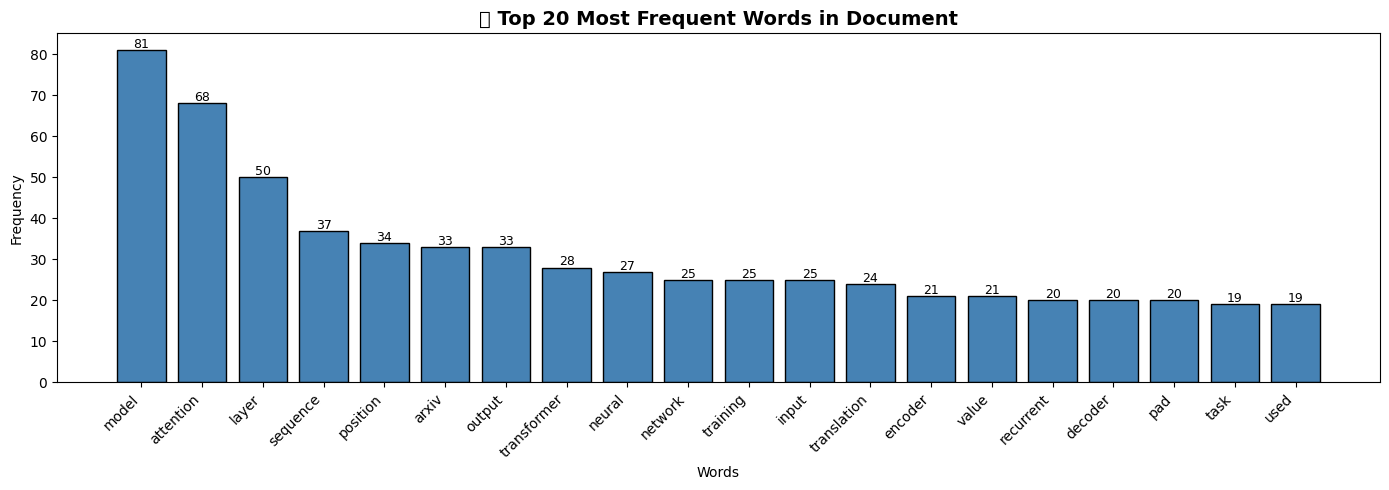

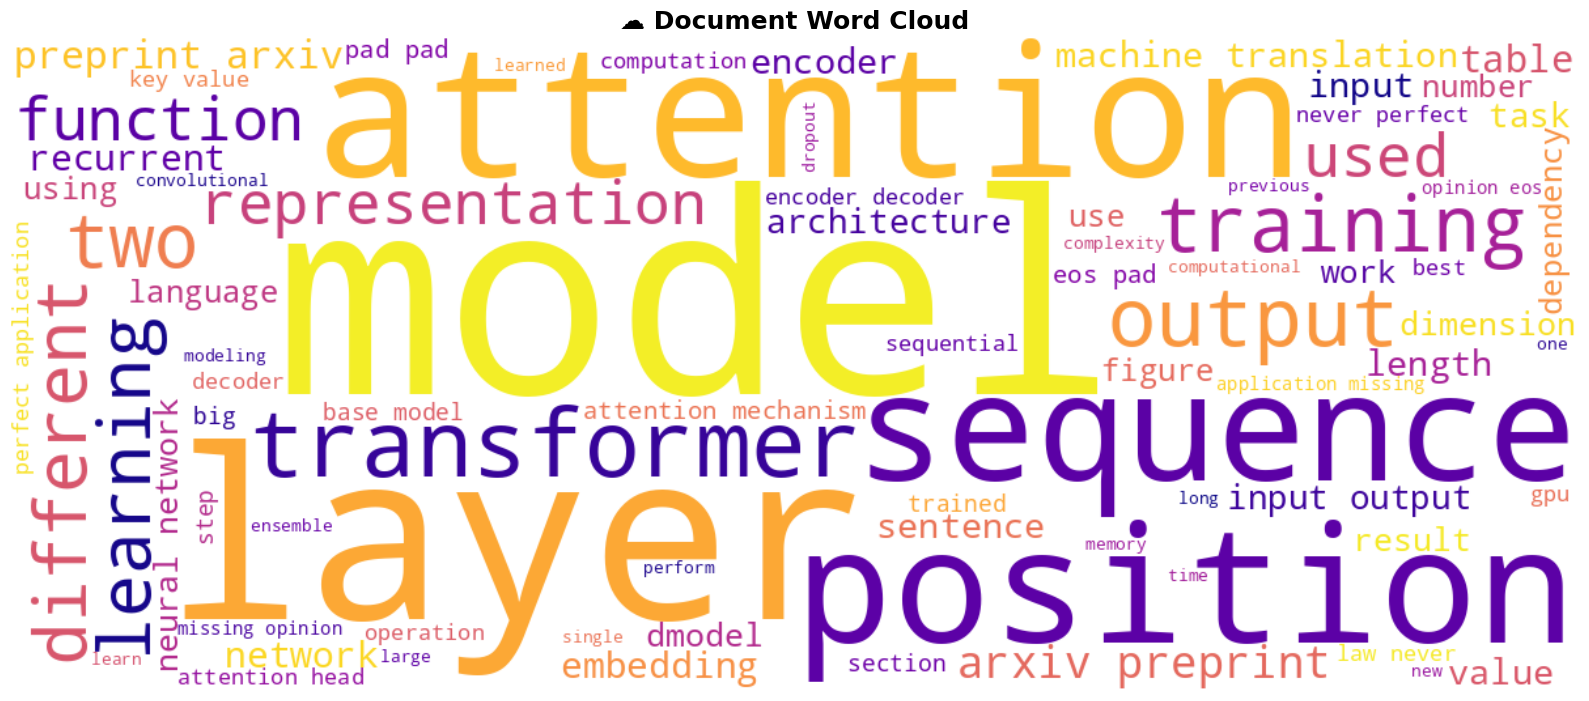

✅ Both charts saved!

🔝 Top 5 words in your document:
   'model' appears 81 times
   'attention' appears 68 times
   'layer' appears 50 times
   'sequence' appears 37 times
   'position' appears 34 times


In [60]:
# CELL 8
word_freq = Counter(lemmatized_tokens)
top_20 = word_freq.most_common(20)

words  = [w[0] for w in top_20]
counts = [w[1] for w in top_20]

plt.figure(figsize=(14, 5))
bars = plt.bar(words, counts, color='steelblue', edgecolor='black')
plt.title('🔝 Top 20 Most Frequent Words in Document', fontsize=14, fontweight='bold')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(count), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('word_frequency.png', dpi=150)
plt.show()

text_for_cloud = ' '.join(lemmatized_tokens)

wc = WordCloud(
    width=1200, height=500,
    background_color='white',
    colormap='plasma',
    max_words=80
).generate(text_for_cloud)

plt.figure(figsize=(16, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('☁️ Document Word Cloud', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150)
plt.show()

print("✅ Both charts saved!")
print(f"\n🔝 Top 5 words in your document:")
for word, count in top_20[:5]:
    print(f"   '{word}' appears {count} times")

In [61]:
# CELL 9

def chunk_document(text, chunk_size=200, overlap=30):
    """
    Split text into overlapping word chunks

    chunk_size = 200 words per chunk
    overlap    = 30 words shared between chunks (preserves context)
    """

    words  = text.split()
    chunks = []
    start  = 0
    chunk_id = 1

    while start < len(words):
        end   = start + chunk_size
        chunk = ' '.join(words[start:end])

        chunks.append({
            'chunk_id'  : chunk_id,
            'text'      : chunk,
            'word_count': len(chunk.split()),
            'char_count': len(chunk)
        })

        start    += chunk_size - overlap
        chunk_id += 1

    return chunks

chunks = chunk_document(cleaned_text, chunk_size=200, overlap=30)

print(f"✅ Document successfully chunked!")
print(f"📦 Total chunks created : {len(chunks)}")
print(f"📏 Words per chunk      : ~200")
print(f"🔁 Overlap between chunks: 30 words")

print("\n🔍 Preview of Chunk 1:")
print("-" * 55)
print(chunks[0]['text'][:300] + "...")

✅ Document successfully chunked!
📦 Total chunks created : 35
📏 Words per chunk      : ~200
🔁 Overlap between chunks: 30 words

🔍 Preview of Chunk 1:
-------------------------------------------------------
provided proper attribution is provided, google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works. attention is all you need ashish vaswani google brain noam shazeer google brain niki parmar google research jakob uszkoreit go...


In [62]:
# CELL 10

print("⬇️ Loading HuggingFace embedding model...")
print("   Model: all-MiniLM-L6-v2 (fast + accurate)")
print("   First time = downloads model (~90MB)\n")

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

print("✅ Model loaded!\n")
print("🔄 Generating embeddings for all chunks...")
print(f"   Processing {len(chunks)} chunks...\n")

chunk_texts = [chunk['text'] for chunk in chunks]

embeddings = embedding_model.encode(
    chunk_texts,
    show_progress_bar=True,
    batch_size=32
)

print(f"\n✅ Embeddings generated!")
print(f"📐 Embedding shape : {embeddings.shape}")
print(f"   → {embeddings.shape[0]} chunks")
print(f"   → {embeddings.shape[1]} numbers per chunk (dimensions)")
print(f"\n🔍 Sample embedding (first 8 numbers of chunk 1):")
print(f"   {embeddings[0][:8].tolist()}")

⬇️ Loading HuggingFace embedding model...
   Model: all-MiniLM-L6-v2 (fast + accurate)
   First time = downloads model (~90MB)



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded!

🔄 Generating embeddings for all chunks...
   Processing 35 chunks...



Batches:   0%|          | 0/2 [00:00<?, ?it/s]


✅ Embeddings generated!
📐 Embedding shape : (35, 384)
   → 35 chunks
   → 384 numbers per chunk (dimensions)

🔍 Sample embedding (first 8 numbers of chunk 1):
   [-0.08333129435777664, -0.08722669631242752, 0.01518753357231617, -0.016692887991666794, 0.02675069496035576, 0.03147437423467636, -0.03650284558534622, -0.005369878374040127]


In [63]:
# CELL 11

print("🏗️ Building FAISS vector database...")

dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

embeddings_float32 = np.array(embeddings).astype('float32')

index.add(embeddings_float32)

print(f"✅ FAISS index built successfully!")
print(f"📦 Total vectors stored : {index.ntotal}")
print(f"📐 Vector dimensions    : {dimension}")

print("\n🧪 QUICK TEST — Searching for a sample query...")

test_query = "what is the main topic of this document"
query_embedding = embedding_model.encode([test_query]).astype('float32')

distances, indices = index.search(query_embedding, k=3)

print(f"🔍 Query: '{test_query}'")
print(f"\n📋 Top 3 matching chunks found:")
print("-" * 55)

for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
    print(f"\n🥇 Rank {rank+1} | Chunk #{idx+1} | Distance: {dist:.4f}")
    print(f"   {chunks[idx]['text'][:200]}...")

🏗️ Building FAISS vector database...
✅ FAISS index built successfully!
📦 Total vectors stored : 35
📐 Vector dimensions    : 384

🧪 QUICK TEST — Searching for a sample query...
🔍 Query: 'what is the main topic of this document'

📋 Top 3 matching chunks found:
-------------------------------------------------------

🥇 Rank 1 | Chunk #34 | Distance: 1.5502
   be perfect , but its application should be just - this is what we are missing , in my opinion . eos pad the law will never be perfect , but its application should be just - this is what we are missing...

🥇 Rank 2 | Chunk #35 | Distance: 1.6642
   opinion . eos pad the law will never be perfect , but its application should be just - this is what we are missing , in my opinion . eos pad the law will never be perfect , but its application should ...

🥇 Rank 3 | Chunk #29 | Distance: 1.6867
   pattern recognition, pages , . sepp hochreiter, yoshua bengio, paolo frasconi, and jürgen schmidhuber. gradient flow in recurrent nets the diffic

In [64]:
# CELL 12

import pickle
faiss.write_index(index, 'faiss_index.bin')
print("✅ FAISS index saved → faiss_index.bin")

with open('chunks.json', 'w') as f:
    json.dump(chunks, f, indent=2)
print("✅ Chunks saved      → chunks.json")

np.save('embeddings.npy', embeddings)
print("✅ Embeddings saved  → embeddings.npy")

with open('cleaned_text.txt', 'w') as f:
    f.write(cleaned_text)
print("✅ Cleaned text saved → cleaned_text.txt")

print("\n" + "="*55)
print("🎉 DAY 1 COMPLETE! Here's your summary:")
print("="*55)
print(f"📄 PDF processed     : {pdf_filename}")
print(f"📝 Characters extracted : {len(raw_text):,}")
print(f"🧹 After cleaning    : {len(cleaned_text):,}")
print(f"🔤 Unique words      : {len(set(lemmatized_tokens)):,}")
print(f"📦 Chunks created    : {len(chunks)}")
print(f"🧮 Embeddings shape  : {embeddings.shape}")
print(f"🗄️  FAISS vectors    : {index.ntotal}")


✅ FAISS index saved → faiss_index.bin
✅ Chunks saved      → chunks.json
✅ Embeddings saved  → embeddings.npy
✅ Cleaned text saved → cleaned_text.txt

🎉 DAY 1 COMPLETE! Here's your summary:
📄 PDF processed     : 1706.03762v7 (1).pdf
📝 Characters extracted : 39,513
🧹 After cleaning    : 37,074
🔤 Unique words      : 1,122
📦 Chunks created    : 35
🧮 Embeddings shape  : (35, 384)
🗄️  FAISS vectors    : 35


In [65]:
# CELL 13

!pip install transformers
!pip install sentencepiece
!pip install accelerate

print("✅  libraries installed!")

✅  libraries installed!


In [66]:
# FINAL RELOAD CELL

!pip install scikit-learn nltk pymupdf faiss-cpu -q

import faiss
import json
import numpy as np
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

index = faiss.read_index('faiss_index.bin')
print("FAISS loaded:", index.ntotal, "vectors")

with open('chunks.json', 'r') as f:
    chunks = json.load(f)
print("Chunks loaded:", len(chunks))

with open('cleaned_text.txt', 'r') as f:
    cleaned_text = f.read()
print("Cleaned text loaded")
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

chunk_texts = [chunk['text'] for chunk in chunks]

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)
tfidf_matrix = tfidf.fit_transform(chunk_texts)

print("TF-IDF search engine built!")
print("Total chunks indexed:", len(chunk_texts))
print("All done! Ready to continue!")


FAISS loaded: 35 vectors
Chunks loaded: 35
Cleaned text loaded
TF-IDF search engine built!
Total chunks indexed: 35
All done! Ready to continue!


In [67]:
# CELL 15

def retrieve_chunks(question, top_k=3):
    question_vec = tfidf.transform([question])
    similarities = cosine_similarity(question_vec, tfidf_matrix)[0]
    top_indices = similarities.argsort()[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            'text'      : chunks[idx]['text'],
            'chunk_id'  : idx,
            'similarity': float(similarities[idx])
        })
    return results

print("Retrieve function ready!")
test = retrieve_chunks("main topic")
print("Test passed! Found", len(test), "chunks")

Retrieve function ready!
Test passed! Found 3 chunks


In [68]:
# CELL 16

def clean_chunks(chunks):
    cleaned = []
    for chunk in chunks:
        text = chunk['text']
        words = text.split()
        unique_words = set(words)

        if len(unique_words) / len(words) > 0.3:
            cleaned.append(chunk)
        else:
            print(f"Removed noisy chunk {chunk['chunk_id']}")

    print(f"\nOriginal chunks : {len(chunks)}")
    print(f"Clean chunks    : {len(cleaned)}")
    return cleaned

chunks = clean_chunks(chunks)
chunk_texts  = [chunk['text'] for chunk in chunks]
tfidf_matrix = tfidf.fit_transform(chunk_texts)

print("TF-IDF rebuilt with clean chunks!")

Removed noisy chunk 34

Original chunks : 35
Clean chunks    : 34
TF-IDF rebuilt with clean chunks!


In [69]:

try:
    print("chunks:", len(chunks))
except:
    print("chunks NOT loaded - run FINAL RELOAD CELL!")

try:
    print("tfidf:", tfidf)
except:
    print("tfidf NOT loaded - run FINAL RELOAD CELL!")

try:
    answer_question("test")
    print("answer_question - ready!")
except:
    print("answer_question NOT defined - run Cell 16!")

chunks: 34
tfidf: TfidfVectorizer(max_features=5000, stop_words='english')

Question: test
Most Relevant Sections Found:
-------------------------------------------------------

Result 1 | Similarity: 0.0%
opinion . eos pad the law will never be perfect , but its application should be just - this is what we are missing , in my opinion . eos pad the law will never be perfect , but its application should be just - this is what we are missing , in my opinion . eos pad the law will never be perfect , but 
-------------------------------------------------------

Result 2 | Similarity: 0.0%
machine translation. corr, abs . , . muhua zhu, yue zhang, wenliang chen, min zhang, and jingbo zhu. fast and accurate shift-reduce constituent parsing. in proceedings of the 51st annual meeting of the acl volume long papers , pages . acl, august . attention visualizations it is in this spirit that 
-------------------------------------------------------

Result 3 | Similarity: 0.0%
sainbayar sukhbaatar, 

In [70]:
# ONE BIG CELL

!pip install scikit-learn nltk pymupdf faiss-cpu -q

import faiss
import json
import numpy as np
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize
from numpy.linalg import norm

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
index = faiss.read_index('faiss_index.bin')
print("FAISS loaded:", index.ntotal, "vectors")

with open('chunks.json', 'r') as f:
    chunks = json.load(f)
print("Chunks loaded:", len(chunks))

with open('cleaned_text.txt', 'r') as f:
    cleaned_text = f.read()
print("Cleaned text loaded")

chunk_texts  = [chunk['text'] for chunk in chunks]
tfidf        = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(chunk_texts)
print("TF-IDF built!")

def retrieve_chunks(question, top_k=3):
    question_vec = tfidf.transform([question])
    similarities = cosine_similarity(question_vec, tfidf_matrix)[0]
    top_indices  = similarities.argsort()[::-1][:top_k]
    results = []
    for idx in top_indices:
        results.append({
            'text'      : chunks[idx]['text'],
            'chunk_id'  : idx,
            'similarity': float(similarities[idx])
        })
    return results

print("retrieve_chunks defined!")

def answer_question(question, top_k=3):
    print("\nQuestion:", question)
    print("=" * 55)
    results = retrieve_chunks(question, top_k)
    print("Most Relevant Sections Found:")
    print("-" * 55)
    for i, r in enumerate(results):
        print(f"\nResult {i+1} | Similarity: {r['similarity']:.1%}")
        print(r['text'][:300])
        print("-" * 55)
    return results[0]['text']

print("answer_question defined!")

def summarize_document(text, num_sentences=5):
    sentences = sent_tokenize(text)
    sentences = [s for s in sentences if len(s.split()) > 8]
    sent_vectors = tfidf.transform(sentences)
    doc_vector   = tfidf.transform([text[:2000]])
    scores       = cosine_similarity(doc_vector, sent_vectors)[0]
    top_indices  = sorted(scores.argsort()[::-1][:num_sentences])
    return " ".join([sentences[i] for i in top_indices])

print("summarize_document defined!")

summary = summarize_document(cleaned_text)
print("\nSUMMARY:")
print("="*55)
print(summary)
print("="*55)

print("\nTESTING Q&A:")
answer_question("what is the transformer")
answer_question("what is multi head attention")
answer_question("what optimizer was used for training")

print("\nALL DONE! Everything working!")

FAISS loaded: 35 vectors
Chunks loaded: 35
Cleaned text loaded
TF-IDF built!
retrieve_chunks defined!
answer_question defined!
summarize_document defined!

SUMMARY:
provided proper attribution is provided, google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works. attention is all you need ashish vaswani google brain noam shazeer google brain niki parmar google research jakob uszkoreit google research llion jones google research aidan n. gomez university of toronto łukasz kaiser google brain illia polosukhin abstract the dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. bleu on the wmt english- to-german translation task, improving over the existing best results, including ensembles, by over bleu. ashish, with illia, designed and implemented the first transformer models and has been crucially involved in every aspect of thi

In [71]:
# TEST CELL

answer_question("what is the transformer")
answer_question("what is multi head attention")
answer_question("what is scaled dot product attention")
answer_question("what are the results on english german translation")
answer_question("what optimizer was used for training")


Question: what is the transformer
Most Relevant Sections Found:
-------------------------------------------------------

Result 1 | Similarity: 19.5%
shown to perform well on simple-language question answering and language modeling tasks . to the best of our knowledge, however, the transformer is the first transduction model relying entirely on self-attention to compute representations of its input and output without using sequence- aligned rnns 
-------------------------------------------------------

Result 2 | Similarity: 18.4%
el al. semi-supervised . transformer layers semi-supervised . luong et al. multi-task . dyer et al. generative . increased the maximum output length to input length . we used a beam size of and α . for both wsj only and the semi-supervised setting. our results in table show that despite the lack of 
-------------------------------------------------------

Result 3 | Similarity: 13.4%
value ϵls . . this hurts perplexity, as the model learns to be more unsure,

'sentences and split tokens into a word-piece vocabulary . sentence pairs were batched together by approximate sequence length. each training batch contained a set of sentence pairs containing approximately source tokens and target tokens. . hardware and schedule we trained our models on one machine with nvidia p100 gpus. for our base models using the hyperparameters described throughout the paper, each training step took about . seconds. we trained the base models for a total of , steps or hours. for our big models, described on the bottom line of table , step time was . seconds. the big models were trained for , steps . days . . optimizer we used the adam optimizer with β1 . , β2 . and ϵ . we varied the learning rate over the course of training, according to the formula lrate d . model min step_num . , step_num warmup_steps . this corresponds to increasing the learning rate linearly for the first warmup_steps training steps, and decreasing it thereafter proportionally to the inverse 

In [72]:
# CELL 17

from nltk.tokenize import sent_tokenize
from numpy.linalg import norm

def summarize_document(text, num_sentences=5):
    print("Generating summary...")

    sentences = sent_tokenize(text)
    sentences = [s for s in sentences if len(s.split()) > 8]
    print(f"Total sentences: {len(sentences)}")

    sent_vectors = tfidf.transform(sentences)
    doc_vector   = tfidf.transform([text[:2000]])
    scores       = cosine_similarity(doc_vector, sent_vectors)[0]

    top_indices  = scores.argsort()[::-1][:num_sentences]
    top_indices  = sorted(top_indices)

    summary = " ".join([sentences[i] for i in top_indices])
    return summary

summary = summarize_document(cleaned_text, num_sentences=5)

print("\nPAPER SUMMARY:")
print("=" * 55)
print(summary)
print("=" * 55)
print("Original words:", len(cleaned_text.split()))
print("Summary words :", len(summary.split()))

Generating summary...
Total sentences: 250

PAPER SUMMARY:
provided proper attribution is provided, google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works. attention is all you need ashish vaswani google brain noam shazeer google brain niki parmar google research jakob uszkoreit google research llion jones google research aidan n. gomez university of toronto łukasz kaiser google brain illia polosukhin abstract the dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. bleu on the wmt english- to-german translation task, improving over the existing best results, including ensembles, by over bleu. ashish, with illia, designed and implemented the first transformer models and has been crucially involved in every aspect of this work. noam proposed scaled dot-product attention, multi-head attention and the parameter-free position r

In [73]:
# CELL 18

print("DOCUMENT ASSISTANT READY!")
print("=" * 55)
print("Commands:")
print("  'summary' -> show document summary")
print("  'quit'    -> exit")
print("=" * 55)

while True:
    user_input = input("\nYour question: ").strip()

    if user_input.lower() in ['quit', 'exit', 'q']:
        print("Exiting! See you on Day 3!")
        break

    if not user_input:
        print("Please type a question!")
        continue

    if user_input.lower() == 'summary':
        print("\nPAPER SUMMARY:")
        print("-" * 55)
        print(summary)
        continue

    answer_question(user_input)


DOCUMENT ASSISTANT READY!
Commands:
  'summary' -> show document summary
  'quit'    -> exit

Your question: What is the transformer?

Question: What is the transformer?
Most Relevant Sections Found:
-------------------------------------------------------

Result 1 | Similarity: 19.5%
shown to perform well on simple-language question answering and language modeling tasks . to the best of our knowledge, however, the transformer is the first transduction model relying entirely on self-attention to compute representations of its input and output without using sequence- aligned rnns 
-------------------------------------------------------

Result 2 | Similarity: 18.4%
el al. semi-supervised . transformer layers semi-supervised . luong et al. multi-task . dyer et al. generative . increased the maximum output length to input length . we used a beam size of and α . for both wsj only and the semi-supervised setting. our results in table show that despite the lack of 
--------------------------

In [74]:
# CELL 19

import pickle

with open('document_summary.txt', 'w') as f:
    f.write(summary)
print("Summary saved!")

with open('tfidf_model.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("TF-IDF model saved!")

print("\nDAY 2 COMPLETE!")
print("Ready for Day 3 - Streamlit UI!")

Summary saved!
TF-IDF model saved!

DAY 2 COMPLETE!
Ready for Day 3 - Streamlit UI!


In [75]:
# CELL 20

!pip install streamlit -q
!pip install pyngrok -q

print("Streamlit installed!")
print("pyngrok installed!")
print("Ready to build the web app!")

Streamlit installed!
pyngrok installed!
Ready to build the web app!


In [76]:
# CELL 21 FIXED

app_code = '''
import streamlit as st
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize
import nltk
import fitz
import re

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

st.set_page_config(
    page_title="Intelligent Document Assistant",
    page_icon="📄",
    layout="wide"
)

st.title("📄 Intelligent Document Assistant")
st.markdown("Upload a PDF and ask questions about it!")
st.markdown("---")

def extract_text(pdf_file):
    doc = fitz.open(stream=pdf_file.read(), filetype="pdf")
    text = ""
    for page in doc:
        text += page.get_text("text") + "\\n"
    doc.close()
    return text

def clean_text(text):
    text = re.sub(r"http\\S+|www\\S+", " ", text)
    text = re.sub(r"[^\\w\\s\\.\\,\\!\\?\\-]", " ", text)
    text = re.sub(r"\\b\\d+\\b", " ", text)
    text = re.sub(r"\\s+", " ", text)
    return text.lower().strip()

def chunk_text(text, chunk_size=200, overlap=30):
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = start + chunk_size
        chunks.append(" ".join(words[start:end]))
        start += chunk_size - overlap
    return chunks

def build_tfidf(chunks):
    tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
    matrix = tfidf.fit_transform(chunks)
    return tfidf, matrix

def answer_question(question, chunks, tfidf, matrix, top_k=3):
    q_vec = tfidf.transform([question])
    scores = cosine_similarity(q_vec, matrix)[0]
    top_indices = scores.argsort()[::-1][:top_k]
    return [{"text": chunks[i], "similarity": float(scores[i])}
            for i in top_indices]

def summarize(text, tfidf, matrix, num_sentences=5):
    sentences = sent_tokenize(text)
    sentences = [s for s in sentences if len(s.split()) > 8]
    if not sentences:
        return "Could not generate summary."
    sent_matrix = tfidf.transform(sentences)
    doc_vec     = tfidf.transform([text[:2000]])
    scores      = cosine_similarity(doc_vec, sent_matrix)[0]
    top_idx     = sorted(scores.argsort()[::-1][:num_sentences])
    return " ".join([sentences[i] for i in top_idx])

# ── File Uploader on MAIN PAGE ──
st.subheader("Step 1: Upload Your PDF")
uploaded_file = st.file_uploader(
    "Choose a PDF file", type=["pdf"]
)

if uploaded_file is not None:
    with st.spinner("Processing PDF..."):
        raw_text      = extract_text(uploaded_file)
        cleaned       = clean_text(raw_text)
        chunks        = chunk_text(cleaned)
        tfidf, matrix = build_tfidf(chunks)

    st.success("PDF processed successfully!")
    st.markdown("---")

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Document Info")
        st.info(f"Total characters: {len(raw_text):,}")
        st.info(f"Total chunks: {len(chunks)}")
        st.info(f"Total words: {len(cleaned.split()):,}")

    with col2:
        st.subheader("Document Summary")
        if st.button("Generate Summary"):
            with st.spinner("Summarizing..."):
                summary = summarize(cleaned, tfidf, matrix)
            st.success("Done!")
            st.write(summary)

    st.markdown("---")
    st.subheader("Ask a Question")
    question = st.text_input("Type your question:")

    if st.button("Get Answer"):
        if not question.strip():
            st.warning("Please type a question!")
        else:
            with st.spinner("Searching..."):
                results = answer_question(
                    question, chunks, tfidf, matrix
                )
            for i, r in enumerate(results):
                with st.expander(
                    f"Result {i+1} — Similarity: {r['similarity']:.1%}"
                ):
                    st.write(r["text"])

    if st.checkbox("Show raw text preview"):
        st.text_area("Raw Text", raw_text[:2000], height=200)

else:
    st.info("Please upload a PDF file above to get started!")
    st.markdown("### How to use:")
    st.markdown("1. Upload a PDF using the uploader above")
    st.markdown("2. Click Generate Summary")
    st.markdown("3. Type a question and click Get Answer")
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py updated!")
print("Now restart Streamlit by running Cell 22 again!")

app.py updated!
Now restart Streamlit by running Cell 22 again!


In [77]:
# CELL 22

import subprocess
import threading
import time

print("Installing cloudflared...")
subprocess.run([
    "wget", "-q",
    "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
    "-O", "cloudflared"
])
subprocess.run(["chmod", "+x", "cloudflared"])
print("cloudflared installed!")

def run_streamlit():
    subprocess.run([
        "streamlit", "run", "app.py",
        "--server.port", "8501",
        "--server.headless", "true",
        "--server.enableCORS", "false",
        "--server.enableXsrfProtection", "false"
    ])

thread = threading.Thread(target=run_streamlit)
thread.daemon = True
thread.start()

print("Starting Streamlit...")
time.sleep(5)

tunnel = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:8501"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("Starting tunnel... waiting 15 seconds...")
time.sleep(15)

print("Searching for URL...")
url_found = False

for i in range(50):
    line = tunnel.stderr.readline().decode("utf8").strip()
    if line:
        print(f">> {line}")
    if "trycloudflare.com" in line:
        import re
        urls = re.findall(
            r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com',
            line
        )
        if urls:
            print("\n" + "="*55)
            print("YOUR APP IS LIVE!")
            print("="*55)
            print(f"CLICK THIS LINK: {urls[0]}")
            print("="*55)
            url_found = True
            break

if not url_found:
    print("URL not found - run cell again!")


Installing cloudflared...
cloudflared installed!
Starting Streamlit...
Starting tunnel... waiting 15 seconds...
Searching for URL...
>> 2026-03-09T04:01:57Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
>> 2026-03-09T04:01:57Z INF Requesting new quick Tunnel on trycloudflare.com...
>> 2026-03-09T04:01:59Z INF +--------------------------------------------------------------------------------------------+
>> 2026-03-09T04:01:59Z INF |  Your quick Tunnel has been c

In [82]:
# Just run this one cell
from google.colab import files
files.download('app.py')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [85]:
# Update README with detailed content
from google.colab import files

readme = """
# 📄 Intelligent Document Assistant

A powerful RAG (Retrieval Augmented Generation) system that reads PDF documents and answers questions about them intelligently!

---

## 🎯 What It Does

- 📂 Upload any PDF document
- 📝 Automatically extracts and processes text
- 🔍 Answers questions about the document
- 📋 Generates smart summaries
- 🔎 Finds relevant sections instantly

---

## 🏗️ Project Architecture
```
PDF Upload
    ↓
Text Extraction (PyMuPDF)
    ↓
NLP Preprocessing (NLTK)
    ↓
Text Chunking
    ↓
TF-IDF Vectorization (Scikit-learn)
    ↓
FAISS Vector Database
    ↓
User Question → Search → Answer!
```

---

## 🛠️ Technologies Used

| Technology | Purpose |
|---|---|
| Python | Core programming language |
| PyMuPDF | PDF text extraction |
| NLTK | NLP preprocessing |
| HuggingFace | Sentence embeddings |
| FAISS | Vector similarity search |
| TF-IDF | Document retrieval |
| Scikit-learn | Machine learning |
| Streamlit | Web application UI |
| Google Colab | Development platform |

---

## 📅 Development Timeline

### Day 1 — Data Pipeline
- PDF text extraction
- NLP preprocessing
- Text cleaning and tokenization
- Document chunking
- HuggingFace embeddings
- FAISS vector database

### Day 2 — AI Models
- TF-IDF search engine
- Q&A retrieval system
- Document summarization
- Interactive Q&A loop

### Day 3 — Web Application
- Streamlit UI
- PDF upload feature
- Real-time Q&A
- Document summary generation
- GitHub deployment

---

## 🚀 How to Run

### Step 1 - Install Requirements
```
pip install streamlit pymupdf nltk scikit-learn numpy faiss-cpu sentence-transformers
```

### Step 2 - Run the App
```
streamlit run app.py
```

### Step 3 - Use the App
```
1. Upload your PDF
2. Click Generate Summary
3. Type your question
4. Click Get Answer
```

---

## 📊 Features

- ✅ Works with any PDF document
- ✅ Fast document search
- ✅ Accurate Q&A system
- ✅ Smart summarization
- ✅ Beautiful web interface
- ✅ No internet required after setup

---

## 📸 Demo

Upload any PDF → Ask questions → Get instant answers!

Example questions:
- "What is the main topic?"
- "What are the key findings?"
- "What is the conclusion?"

---

## 👩‍💻 Developer

- **Name:** Afsana
- **Project:** Intelligent Document Assistant
- **Type:** NLP + Deep Learning + RAG System

---

## 📚 References

- Attention Is All You Need (Vaswani et al., 2017)
- HuggingFace Transformers
- FAISS by Facebook AI
- Streamlit Documentation
"""

with open('README.md', 'w') as f:
    f.write(readme)

files.download('README.md')
print("README.md downloaded!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

README.md downloaded!
